In [2]:
from openai import OpenAI
import os 
import dotenv
dotenv.load_dotenv()

client = OpenAI(api_key=os.getenv("OPEN_AI_API"))

file = client.files.create(
    file = open("Sample/sample_data.pdf" , "rb"),
    purpose = "user_data"
)

model = "gpt-5.1"

In [3]:
# Extract Text 
completion = client.chat.completions.create(
    model = model,
    messages = [
        {
            "role" : "user",
            "content" : [
                {
                    "type" : "file",
                    "file" : {
                        "file_id" : file.id
                    }
                },
                {
                    "type" : "text" ,
                    "text" : "Extract the text content from the file. Exclude text from tables or images."
                }
            ]
        }
    ]
)

In [9]:
print(completion.choices[0].message.content)

This is a great chapter


In [12]:
# Extracting the table 
completion = client.chat.completions.create(
    model=model,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "file",
                    "file": {
                        "file_id": file.id
                    }
                },
                {
                    "type": "text",
                    "text": "Extract the tables from the file. Return them as Markdown tables."
                }
            ]
        }
    ]
)

In [13]:
print(completion.choices[0].message.content)

Here are the tables from the file, converted to Markdown.

**Table 1 (single row):**

| Revision | Year |
|---------|------|
| 0.0.1   | 2025 |

**Table 2 (book details):**

| Book          | Revision | Year | Author           |
|---------------|----------|------|------------------|
| Memory and RAG| 0.1.0    | 2026 | A great researcher |
| RAG and AI    | 0.0.1    | 2025 |                  |


In [ ]:
# Extracting image
completion = client.chat.completions.create(
    model = model,
    messages = [
        {
            "role" : "user" ,
            "content" : [
                {
                    "type" : "file",
                    "file" : {
                        "file_id" : file.id, 
                    }
                },
                {
                    "type" : "text",
                    "text" : "Extract the image from the pdf file. return as base64-encoded string.only base64 string nothing else."
                }
            ]
        }
    ]
)

print(completion.choices[0].message.content)

Base64 string length : 27460
First 100 char of base64 : iVBORw0KGgoAAAANSUhEUgAAAFwAAABcCAIAAABsjUUPAAAACXBIWXMAAA7EAAAOxAGVKw4bAABQI0lEQVR4nGS8Z1QU29otXDSd...


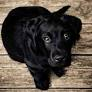

Image extracted


In [15]:
# Extract image using PyMuPDFm, encode to base64, then visualize
import fitz
import base64
from IPython.display import Image, display 
import io 

pdf_path = "Sample/sample_data.pdf"
pdf_document = fitz.open(pdf_path)

# Extract the first image found 
for page_num in range(len(pdf_document)):
    page = pdf_document[page_num]
    image_list = page.get_images(full = True)

    if image_list:
        img = image_list[0]
        xref = img[0]
        pix = fitz.Pixmap(pdf_document,xref)

        if pix.n - pix.alpha < 4:
            img_data = pix.tobytes("png")
        else:
            pix = fitz.Pixmap(fitz.csRGB , pix)
            img_data = pix.tobytes("png")

        base64_String = base64.b64encode(img_data).decode('utf-8')
        print(f"Base64 string length : {len(base64_String)}")
        print(f"First 100 char of base64 : {base64_String[:100]}...")

        decoded_img_data = base64.b64decode(base64_String)

        display(Image(data = decoded_img_data))
        print("Image extracted")

        pix = None 
        break 

pdf_document.close()